# Object Detection Inference Optimization - Colab Demo

This notebook demonstrates the complete object detection system with:
- Multiple models (YOLOv8, YOLOv11)
- Multiple optimizations (ONNX, TensorRT)
- FastAPI backend
- Benchmarking and evaluation

**Note:** Use a GPU runtime for best performance!

## 1. Setup and Installation

In [1]:
# Check GPU availability
!nvidia-smi

Tue Apr 14 05:43:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Install required packages
!pip install fastapi uvicorn python-multipart
!pip install opencv-python-headless ultralytics
!pip install onnx onnxruntime-gpu
!pip install pyngrok
!pip install nest-asyncio

print("✅ Installation complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 131.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 10.5 MB/s eta 0:00:00
✅ Installation complete!


## 2. Clone or Upload Project Files

In [4]:
# Option 1: If you have the project in GitHub
# !git clone <your-repo-url>
# %cd <project-directory>

# Option 2: Upload project files manually using Colab's file upload
from google.colab import files
import zipfile
import os

print("Upload your project zip file:")
uploaded = files.upload()

# Extract if zip file
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('.')
        print(f"✅ Extracted {filename}")

!ls -la

Upload your project zip file:


Saving SP26 Homework2 Object Detection.zip to SP26 Homework2 Object Detection.zip
✅ Extracted SP26 Homework2 Object Detection.zip
total 136
drwxr-xr-x 1 root root   4096 Apr 14 05:46  .
drwxr-xr-x 1 root root   4096 Apr 14 05:35  ..
drwxr-xr-x 4 root root   4096 Mar 30 13:34  .config
drwxr-xr-x 3 root root   4096 Apr 14 05:46  __MACOSX
drwxr-xr-x 1 root root   4096 Mar 30 13:34  sample_data
drwxr-xr-x 6 root root   4096 Apr 14 05:46 'SP26 Homework2 Object Detection'
-rw-r--r-- 1 root root 113543 Apr 14 05:46 'SP26 Homework2 Object Detection.zip'


## 3. Quick Test - Single Image Detection

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/test_image.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 114.9ms
Speed: 11.3ms preprocess, 114.9ms inference, 40.9ms postprocess per image at shape (1, 3, 640, 480)


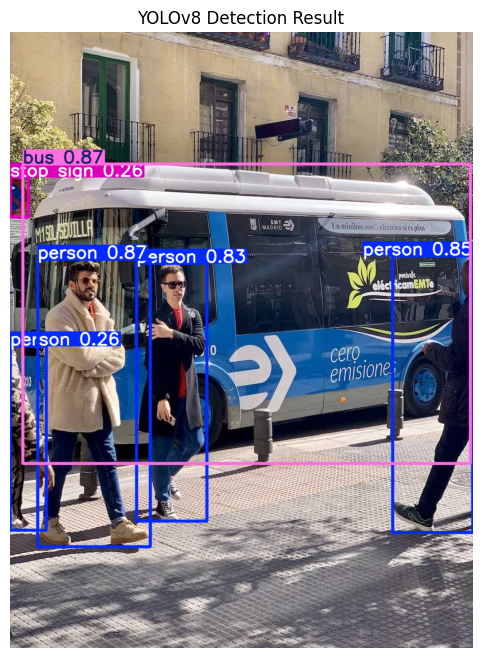

✅ Detection complete!


In [5]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt
import numpy as np

# Load model
model = YOLO('yolov8n.pt')

# Download a sample image
!wget -q https://ultralytics.com/images/bus.jpg -O test_image.jpg

# Run inference
results = model('test_image.jpg')

# Display result
result_img = results[0].plot()
result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(result_img)
plt.axis('off')
plt.title('YOLOv8 Detection Result')
plt.show()

print("✅ Detection complete!")

## 4. Model Optimization - Export to ONNX

In [6]:
# Export to ONNX
model = YOLO('yolov8n.pt')
onnx_path = model.export(format='onnx', dynamic=True, simplify=True)

print(f"✅ ONNX model exported to: {onnx_path}")

# Load and test ONNX model
onnx_model = YOLO(onnx_path)
onnx_results = onnx_model('test_image.jpg')

print("✅ ONNX model works!")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.71'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 295ms
Prepared 2 packages in 46ms
Installed 2 packages in 7ms
 + colorama==0.4.6
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 3.1s, saved as 'yolov8n.onnx' (12.4 MB)

Export complete (3.6s)
Resu

## 5. Speed Benchmark - Compare Models and Optimizations

🔄 Benchmarking YOLOv8n (PyTorch)...
🔄 Benchmarking YOLOv8n (ONNX)...

📊 Benchmark Results:
  Model Backend  Avg Time (ms)       FPS
YOLOv8n PyTorch      15.493951 64.541317
YOLOv8n    ONNX      17.577553 56.890741


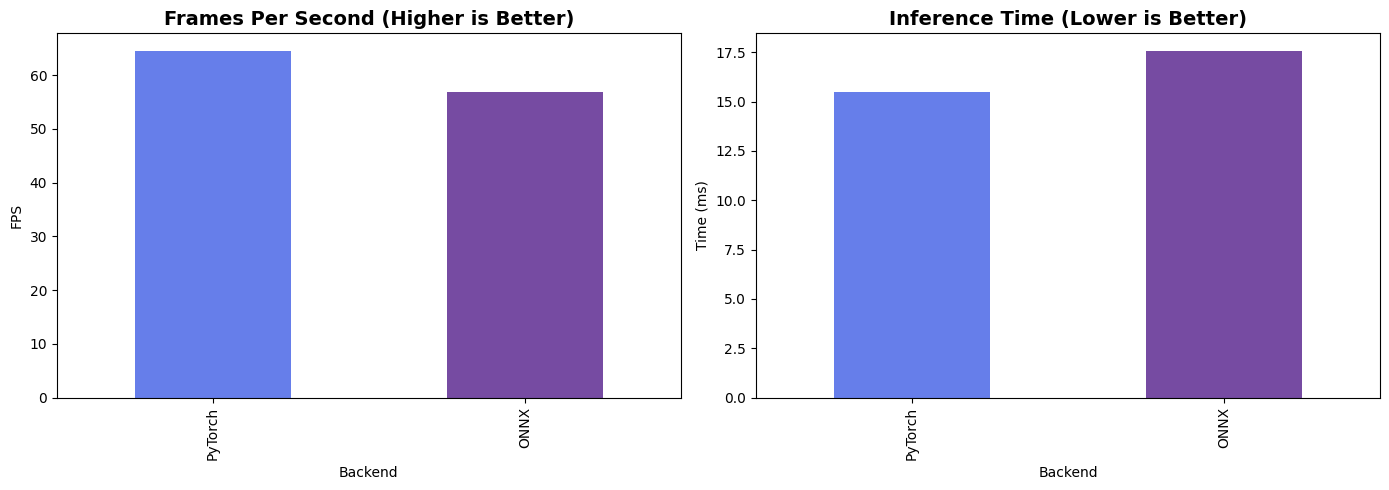


⚡ ONNX Speedup: 0.88x faster than PyTorch


In [7]:
import time
import pandas as pd

def benchmark_model(model, image_path, num_runs=100, warmup=10):
    """Benchmark model inference speed"""
    # Warmup
    for _ in range(warmup):
        _ = model(image_path, verbose=False)

    # Benchmark
    times = []
    for _ in range(num_runs):
        start = time.time()
        _ = model(image_path, verbose=False)
        times.append(time.time() - start)

    return {
        'avg_time': np.mean(times),
        'std_time': np.std(times),
        'fps': 1.0 / np.mean(times)
    }

# Benchmark different configurations
results = []

print("🔄 Benchmarking YOLOv8n (PyTorch)...")
pt_model = YOLO('yolov8n.pt')
pt_result = benchmark_model(pt_model, 'test_image.jpg')
results.append({'Model': 'YOLOv8n', 'Backend': 'PyTorch', **pt_result})

print("🔄 Benchmarking YOLOv8n (ONNX)...")
onnx_result = benchmark_model(onnx_model, 'test_image.jpg')
results.append({'Model': 'YOLOv8n', 'Backend': 'ONNX', **onnx_result})

# Display results
df = pd.DataFrame(results)
df['avg_time_ms'] = df['avg_time'] * 1000
df = df[['Model', 'Backend', 'avg_time_ms', 'fps']]
df.columns = ['Model', 'Backend', 'Avg Time (ms)', 'FPS']

print("\n📊 Benchmark Results:")
print(df.to_string(index=False))

# Visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FPS comparison
df.plot(x='Backend', y='FPS', kind='bar', ax=ax1, legend=False, color=['#667eea', '#764ba2'])
ax1.set_title('Frames Per Second (Higher is Better)', fontsize=14, fontweight='bold')
ax1.set_ylabel('FPS')
ax1.set_xlabel('Backend')

# Inference time comparison
df.plot(x='Backend', y='Avg Time (ms)', kind='bar', ax=ax2, legend=False, color=['#667eea', '#764ba2'])
ax2.set_title('Inference Time (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Time (ms)')
ax2.set_xlabel('Backend')

plt.tight_layout()
plt.show()

speedup = results[0]['avg_time'] / results[1]['avg_time']
print(f"\n⚡ ONNX Speedup: {speedup:.2f}x faster than PyTorch")

## 6. Video Processing Demo

In [8]:
# Download sample video
!wget -q https://github.com/intel-iot-devkit/sample-videos/raw/master/people-detection.mp4 -O test_video.mp4

# Process video
model = YOLO('yolov8n.pt')
results = model.track('test_video.mp4', save=True, conf=0.3)

print("\n✅ Video processing complete!")
print("Output video saved to: runs/detect/predict/test_video.avi")

# Display first frame result
from IPython.display import Video
Video('runs/detect/predict/test_video.avi', width=800)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 241ms
Prepared 1 package in 73ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/596) /content/test_video.mp4: 384x640 (no detections), 77.7ms
video 1/1 (frame 2/5

ValueError: To embed videos, you must pass embed=True (this may make your notebook files huge)
Consider passing Video(url='...')

## 7. Start FastAPI Backend (Optional)

In [9]:
# This will start the API server accessible via ngrok
import nest_asyncio
from pyngrok import ngrok
import uvicorn
import threading

nest_asyncio.apply()

# Set up ngrok tunnel
ngrok_tunnel = ngrok.connect(8000)
print(f"\n🌐 Public URL: {ngrok_tunnel.public_url}")
print("   Use this URL to access the API from anywhere!")

# Note: You need to have the backend code available
# Uncomment below if you have backend/app/main.py
# %cd backend
# !python -m uvicorn app.main:app --host 0.0.0.0 --port 8000

ERROR:pyngrok.process.ngrok:t=2026-04-14T05:49:20+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-14T05:49:20+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-14T05:49:20+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

## 8. Download Dataset from Roboflow (RECOMMENDED)

### Get your Roboflow API key
1. Go to https://app.roboflow.com/settings/api
2. Copy your API key
3. Paste it below

In [10]:
# Install roboflow
!pip install roboflow

print("✅ Roboflow installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 143.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


✅ Roboflow installed!


In [14]:
# Set your API key here
ROBOFLOW_API_KEY = "xxQf7kiFcw5EE9lsZsXl"  # Replace with your actual API key

# Choose a dataset (or use custom)
WORKSPACE = "roboflow-jvuqo"
PROJECT = "fashion-assistant-segmentation"
VERSION = 1

# Popular alternatives:
# WORKSPACE, PROJECT, VERSION = "roboflow-100", "pedestrian-detection", 1  # People detection
# WORKSPACE, PROJECT, VERSION = "microsoft", "coco-dataset", 1  # COCO sample

In [15]:
# Download dataset
from roboflow import Roboflow

print("📥 Downloading dataset from Roboflow...")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download("coco")

print(f"✅ Dataset downloaded to: {dataset.location}")
print(f"\n📊 Dataset includes:")
print(f"  - Training images: {dataset.location}/train")
print(f"  - Validation images: {dataset.location}/valid")
print(f"  - Test images: {dataset.location}/test")
print(f"  - Annotations in COCO format")

📥 Downloading dataset from Roboflow...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fashion-assistant-segmentation-1 in coco:: 100%|██████████| 133/133 [00:00<00:00, 2586.58it/s]

✅ Dataset downloaded to: /content/fashion-assistant-segmentation-1

📊 Dataset includes:
  - Training images: /content/fashion-assistant-segmentation-1/train
  - Validation images: /content/fashion-assistant-segmentation-1/valid
  - Test images: /content/fashion-assistant-segmentation-1/test
  - Annotations in COCO format


## 9. Run Complete Evaluation Workflow

In [16]:
# Run inference on validation set
import os
from ultralytics import YOLO
import json
from pathlib import Path
import time
from tqdm import tqdm

# Set paths
valid_images = Path(dataset.location) / "valid"
annotations_file = valid_images / "_annotations.coco.json"

# Load annotations
with open(annotations_file, 'r') as f:
    gt_data = json.load(f)

print(f"📊 Dataset Stats:")
print(f"  Images: {len(gt_data['images'])}")
print(f"  Annotations: {len(gt_data['annotations'])}")
print(f"  Categories: {len(gt_data['categories'])}")

# Show categories
print(f"\n📋 Categories:")
for cat in gt_data['categories']:
    print(f"  - {cat['name']} (ID: {cat['id']})")

📊 Dataset Stats:
  Images: 12
  Annotations: 13
  Categories: 11

📋 Categories:
  - fashion-assistant (ID: 0)
  - baseball cap (ID: 1)
  - hoodie (ID: 2)
  - jacket (ID: 3)
  - pants (ID: 4)
  - shirt (ID: 5)
  - shorts (ID: 6)
  - sneaker (ID: 7)
  - sunglasses (ID: 8)
  - sweatshirt (ID: 9)
  - t-shirt (ID: 10)


In [17]:
# Run inference with YOLOv8n
model = YOLO('yolov8n.pt')

print("🔄 Running inference on validation set...")

predictions = []
inference_times = []

for img_info in tqdm(gt_data['images'][:50]):  # Test on first 50 images
    img_path = valid_images / img_info['file_name']

    # Run inference
    start = time.time()
    results = model.predict(img_path, conf=0.25, verbose=False)
    inference_times.append(time.time() - start)

    # Parse results
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            predictions.append({
                "image_id": img_info['id'],
                "category_id": int(box.cls[0]),
                "bbox": [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                "score": float(box.conf[0])
            })

avg_time = np.mean(inference_times)
print(f"\n✅ Inference complete!")
print(f"  Avg time: {avg_time*1000:.2f}ms")
print(f"  FPS: {1/avg_time:.2f}")
print(f"  Total detections: {len(predictions)}")

🔄 Running inference on validation set...


100%|██████████| 12/12 [00:00<00:00, 36.65it/s]


✅ Inference complete!
  Avg time: 26.72ms
  FPS: 37.42
  Total detections: 8


In [18]:
# Calculate simple mAP
def calculate_iou(box1, box2):
    """Calculate IoU between two boxes [x, y, w, h]"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)

    if xi2 < xi1 or yi2 < yi1:
        return 0.0

    inter_area = (xi2 - xi1) * (yi2 - yi1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0.0

# Simple mAP calculation
iou_threshold = 0.5
tp = 0
fp = 0
total_gt = len([a for a in gt_data['annotations'] if a['image_id'] <= 50])

matched_gt = set()
for pred in sorted(predictions, key=lambda x: x['score'], reverse=True):
    best_iou = 0
    best_gt = None

    for gt in gt_data['annotations']:
        if gt['image_id'] == pred['image_id'] and gt['id'] not in matched_gt:
            iou = calculate_iou(pred['bbox'], gt['bbox'])
            if iou > best_iou:
                best_iou = iou
                best_gt = gt['id']

    if best_iou >= iou_threshold:
        tp += 1
        matched_gt.add(best_gt)
    else:
        fp += 1

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / total_gt if total_gt > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📈 Evaluation Results (IoU={iou_threshold}):")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  True Positives: {tp}")
print(f"  False Positives: {fp}")
print(f"  Ground Truth: {total_gt}")


📈 Evaluation Results (IoU=0.5):
  Precision: 0.7500
  Recall: 0.4615
  F1-Score: 0.5714
  True Positives: 6
  False Positives: 2
  Ground Truth: 13


In [21]:
# Simple accuracy check
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

# Run validation on dataset
metrics = model.val()

print(f"mAP@0.5: {metrics.box.map50}")
print(f"mAP@0.5:0.95: {metrics.box.map}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco.yaml' images not found, missing path '/content/datasets/coco/val2017.txt'
Unzipping /content/datasets/coco2017labels-segments.zip to /content/datasets/coco...: 100% ━━━━━━━━━━━━ 122232/122232 7.5Kfiles/s 16.4s
Unzipping /content/datasets/coco/images/val2017.zip to /content/datasets/coco/images/val2017...: 100% ━━━━━━━━━━━━ 5001/5001 2.3Kfiles/s 2.2s
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 100% ━━━━━━━━━━━━ 40671/40671 2.2Kfiles/s 18.5s
Unzipping /content/datasets/coco/images/train2017.zip to /content/datasets/coco/images/train2017...: 100% ━━━━━━━━━━━━ 118288/118288 2.2Kfiles/s 52.8s
Dataset download success ✅ (562.4s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 19.9±18.6 MB/s, size: 131.3 KB)

## 10. Compare Multiple Models


🔄 Testing yolov8n...
  Avg time: 17.26ms
  FPS: 57.94

🔄 Testing yolov8s...
  Avg time: 16.94ms
  FPS: 59.04


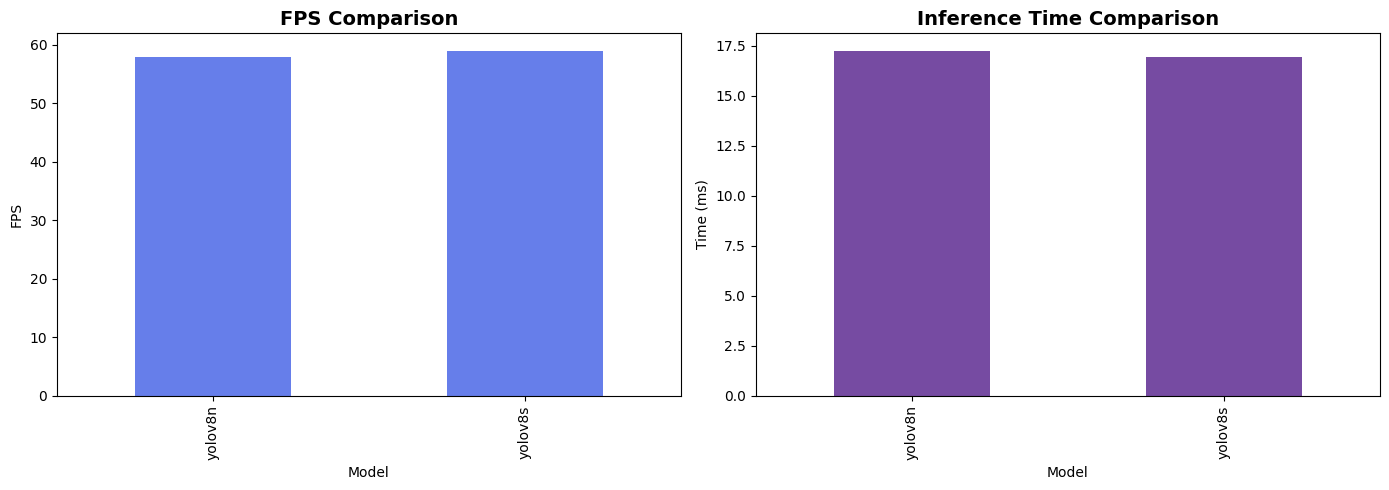


✅ Benchmark complete!


In [19]:
# Test multiple models
models_to_test = ['yolov8n', 'yolov8s']
results_comparison = []

test_img = str(list(valid_images.glob("*.jpg"))[0])

for model_name in models_to_test:
    print(f"\n🔄 Testing {model_name}...")
    model = YOLO(f"{model_name}.pt")

    # Warmup
    for _ in range(5):
        _ = model.predict(test_img, verbose=False)

    # Benchmark
    times = []
    for _ in range(50):
        start = time.time()
        _ = model.predict(test_img, verbose=False)
        times.append(time.time() - start)

    avg_time = np.mean(times)
    results_comparison.append({
        'model': model_name,
        'avg_time_ms': avg_time * 1000,
        'fps': 1 / avg_time
    })

    print(f"  Avg time: {avg_time*1000:.2f}ms")
    print(f"  FPS: {1/avg_time:.2f}")

# Plot comparison
import pandas as pd
df = pd.DataFrame(results_comparison)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df.plot(x='model', y='fps', kind='bar', ax=ax1, legend=False, color='#667eea')
ax1.set_title('FPS Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('FPS')
ax1.set_xlabel('Model')

df.plot(x='model', y='avg_time_ms', kind='bar', ax=ax2, legend=False, color='#764ba2')
ax2.set_title('Inference Time Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Time (ms)')
ax2.set_xlabel('Model')

plt.tight_layout()
plt.show()

print("\n✅ Benchmark complete!")

## 11. Custom Annotation Tool (Optional - For Local Use)

In [20]:
# If you want to create your own annotations locally, use the annotation tool
# This is not needed if you're using Roboflow dataset (already annotated)

print("ℹ️  For custom annotations, download the project and run:")
print("   python evaluation/annotate.py --image_dir your/images --output annotations.json")

ℹ️  For custom annotations, download the project and run:
   python evaluation/annotate.py --image_dir your/images --output annotations.json
